# Analiza nukleotidnih 3-mera

In [1]:
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler
import os
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import numpy as np

In [2]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

In [3]:
from help_functions import build_kmer_dataset,plot_cumulative_variance, apply_pca_transformation,optimize_and_print_kmeans,optimize_and_print_agglomerative, optimize_and_print_gmm, plot_3d, plot_clustering_comparison_3d, run_hantavirus_clustering_pipeline, analyze_clustering_results, extract_kmer_summary

# Učitavanje podataka

In [4]:
complete_sequences_df = pd.read_csv('../data/processed_sequences/final/complete_sequences.csv')

In [5]:
species_counts = complete_sequences_df['Species'].value_counts()
print(species_counts)

Species
Orthohantavirus hantanense       249
Orthohantavirus puumalaense      123
Orthohantavirus dobravaense       37
Orthohantavirus sinnombreense     18
Name: count, dtype: int64


In [6]:
all_sequences_df = pd.read_csv('../data/processed_sequences/final/all_sequences.csv')

In [7]:
total_count = len(all_sequences_df)
species_counts = all_sequences_df['Species'].value_counts()
print(total_count,species_counts)

5179 Species
Orthohantavirus puumalaense      2828
Orthohantavirus hantanense       1667
Orthohantavirus dobravaense       438
Orthohantavirus sinnombreense     246
Name: count, dtype: int64


In [8]:
#all_sequences_df

In [9]:
all_3_mers = build_kmer_dataset(all_sequences_df,3,'all_3_mers.csv')

In [10]:
complete_3_mers = build_kmer_dataset(complete_sequences_df,3,'complete_3_mers.csv')

## Kumulativna objašnjena varijansa (PCA za 3-mere)

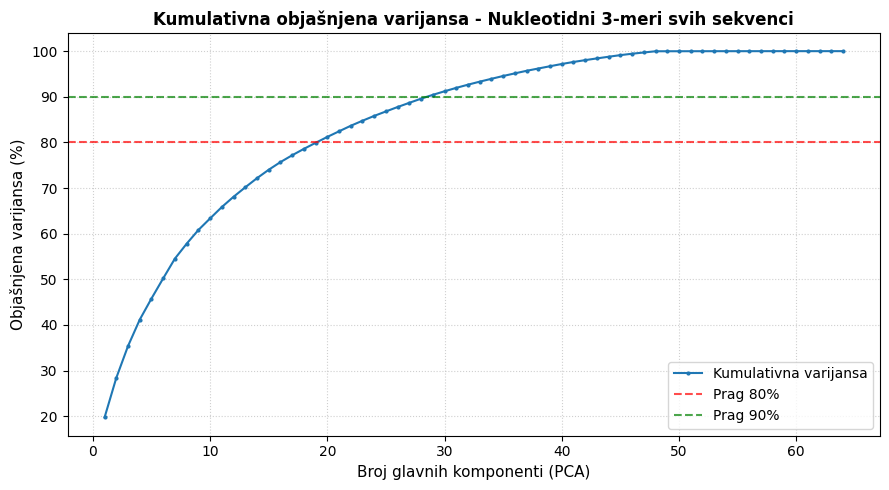

[Nukleotidni 3-meri svih sekvenci] Broj komponenti za 80% varijanse: 20
[Nukleotidni 3-meri svih sekvenci] Broj komponenti za 90% varijanse: 29


In [11]:
plot_cumulative_variance(all_3_mers,'Nukleotidni 3-meri svih sekvenci')

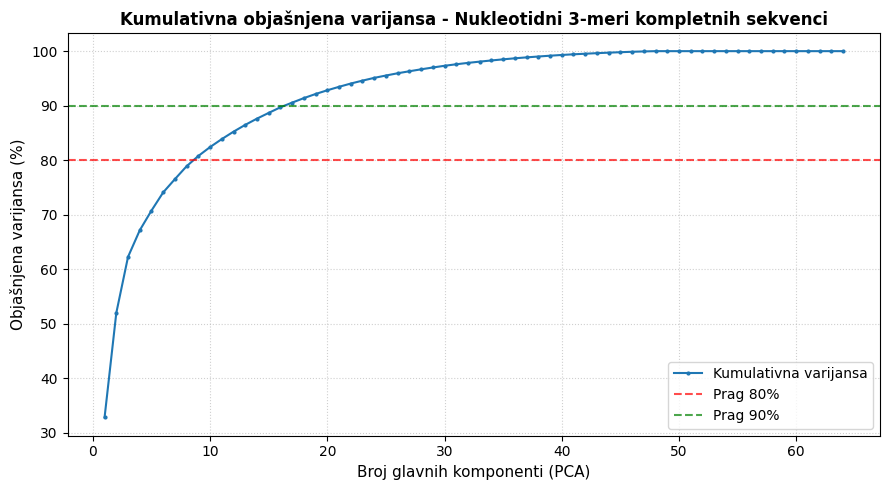

[Nukleotidni 3-meri kompletnih sekvenci] Broj komponenti za 80% varijanse: 9
[Nukleotidni 3-meri kompletnih sekvenci] Broj komponenti za 90% varijanse: 17


In [12]:
plot_cumulative_variance(complete_3_mers,'Nukleotidni 3-meri kompletnih sekvenci')

Rezultati na graficima pokazuju ključnu razliku između dva skupa:
* **Skup svih sekvenci:** 
  * Za pokrivanje 80% varijanse potrebno je **20 glavnih komponenti** (29 za 90%). 
  * Sporiji rast krive je posledica prisustva parcijalnih sekvenci različitih dužina koji unose šum u profile 3-mera.
* **Skup kompletnih sekvenci:** 
  * Prag od 80% varijanse dostiže se sa **9 glavnih komponenti** (17 za 90%), uz dominantan doprinos prvih nekoliko komponenti.


Zadržavanjem komponenti koje objašnjavaju 80% varijanse postignuta je efikasna redukcija dimenzionalnosti.

#  Analiza nukleotidnih 3-mera kompletnih sekvenci

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 7
Način inicijalizacije: k-means++
----------------------------------------
Silueta koeficijent: 0.5559
Davies-Bouldin indeks: 0.7669
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 7
Izabrana metrika: euclidean
Tip povezivanja: complete
----------------------------------------
Silueta koeficijent: 0.5641
Davies-Bouldin indeks: 0.6959
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 4
Tip kovarijanse: spherical
----------------------------------------
Silueta koeficijent: 0.5379
Davies-Bouldin indeks: 0.8741
5. Generisanje uporednog 3D prikaza...


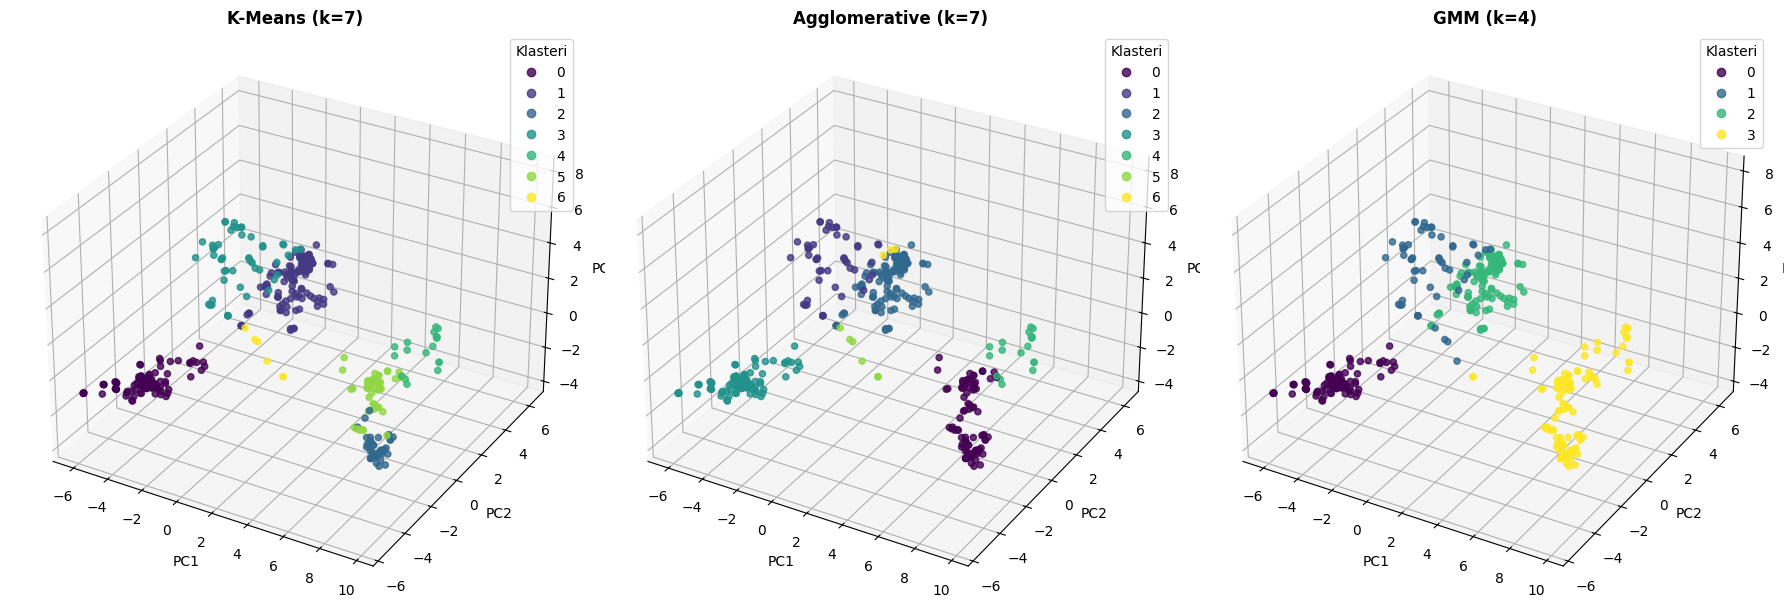

In [13]:
res_complete = run_hantavirus_clustering_pipeline(complete_3_mers, n_components=0.8, plot=True)

### Poređenje rezultata klasterovanja (3-meri kompletnih sekvenci, N = 427)

  * Hijerarhijsko klasterovanje sa potpunim povezivanjem (complete linkage) dalo je najbolje rezultate (silueta koeficijent: 0.5641, Davies-Bouldin indeks: 0.6959), nadmašivši K-Means (0.5559 / 0.7669).
  * Obe metode imaju po 7 klastera.
  * GMM izdvaja četiri klastera (uz sferičnu matricu kovarijanse, silueta koeficijent: 0.5379, DB: 0.8741). 

In [14]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['kmeans'], 
    data= complete_3_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['agglomerative'], 
    data= complete_3_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['gmm'], 
    data= complete_3_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,130,0,0
1,0,129,0
2,0,0,47
3,0,0,53
4,0,0,18
5,0,0,44
6,0,0,6



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,7,86,31,6
1,12,72,39,6
2,0,47,0,0
3,0,0,53,0
4,18,0,0,0
5,0,44,0,0
6,0,0,0,6



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 1 (N=129, pretežno M segment) -> Orthohantavirus hantanense: 72 (55.8%), Orthohantavirus puumalaense: 39 (30.2%), Orthohantavirus dobravaense: 12 (9.3%)
  Klaster 2 (N=47, pretežno S segment) -> Orthohantavirus hantanense: 47 (100.0%)
  Klaster 3 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 4 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 5 (N=44, pretežno S segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 6 (N=6, pretežno S segment) -> Orthohantavirus sinnombreense: 6 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> AAG (Z=1.18), TAG (Z=1.17), TTA (Z=1.10)
  Klaster 1 -> GTG (Z=1.37), TGT (Z=1.34), ACA (Z=1.11)
  Klaster 2 -> GCA (Z=2.00), TCC (Z=1.90), GGG (Z=1.75)
  Kl

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=91, pretežno S segment) -> Orthohantavirus hantanense: 91 (100.0%)
  Klaster 1 (N=50, pretežno S segment) -> Orthohantavirus puumalaense: 50 (100.0%)
  Klaster 2 (N=129, pretežno M segment) -> Orthohantavirus hantanense: 72 (55.8%), Orthohantavirus puumalaense: 39 (30.2%), Orthohantavirus dobravaense: 12 (9.3%)
  Klaster 3 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 4 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 5 (N=6, pretežno S segment) -> Orthohantavirus sinnombreense: 6 (100.0%)
  Klaster 6 (N=3, pretežno S segment) -> Orthohantavirus puumalaense: 3 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> GGG (Z=1.60), GGC (Z=1.57), GCA (Z=1.56)
  Klaster 1 -> ACT (Z=1.90), ATG (Z=1.62), TAT (Z=1.36)
  Klaster 2 -> GTG (Z=1.37), TGT (Z=1.34), ACA (Z=1.11)
  Kla

Segment,L,M,S
Cluster,,,
0,130,0,0
1,0,0,57
2,0,129,0
3,0,0,111



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,7,86,31,6
1,0,0,53,4
2,12,72,39,6
3,18,91,0,2



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 1 (N=57, pretežno S segment) -> Orthohantavirus puumalaense: 53 (93.0%), Orthohantavirus sinnombreense: 4 (7.0%)
  Klaster 2 (N=129, pretežno M segment) -> Orthohantavirus hantanense: 72 (55.8%), Orthohantavirus puumalaense: 39 (30.2%), Orthohantavirus dobravaense: 12 (9.3%)
  Klaster 3 (N=111, pretežno S segment) -> Orthohantavirus hantanense: 91 (82.0%), Orthohantavirus dobravaense: 18 (16.2%), Orthohantavirus sinnombreense: 2 (1.8%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> AAG (Z=1.18), TAG (Z=1.17), TTA (Z=1.10)
  Klaster 1 -> ACT (Z=1.74), ATG (Z=1.48), ACG (Z=1.25)
  Klaster 2 -> GTG (Z=1.37), TGT (Z=1.34), ACA (Z=1.11)
  Klaster 3 -> GGC (Z=1.50), ATC (Z=1.49), GGA (Z=1.48)


### Interpretacija klastera (3-meri kompletnih sekvenci, N = 427)

* **K-Means (k = 7):**
  * **L segment:** Svih 130 sekvenci je smešteno u klaster 0. Klaster je definisan motivima: `AAG`, `TAG` i `TTA`.
  * **M segment:** Svih 129 sekvenci je smešteno u klaster 1, definisan je motivima `GTG`, `TGT` i `ACA`.
  * **S segment:** Deli se na 5 zasebnih klastera, pri čemu je svaki klaster 100% homogen po vrstama:
    * *O. hantanense* se razbija na dva klastera: klaster 2 sa motivima `GCA` i `TCC`, i klaster 5 sa `GGA` i `GGC`.
    * *O. puumalaense* svih 53 sekvenci su smešteni u klaster 3 koji je određen motivina `ACT` i `ATG`.
    * *O. dobravaense* svih 18 sekvenci su smešteni u klaster 4, sa motivima `TCG` (Z = 3.33) i `GAC` (Z = 2.93).
    * *O. sinnombreense* svig 6 sekvenci virusa su smešteni u klaster 6, sa motivima `CGT` (Z=2.60) i `TCA` (Z=2.12)

* **Aglomerativno klasterovanje (complete linkage, k = 7):**
  * L i M segmenti ponovo čine dva odvojena klastera sa istim motivima.
  * S segmenti su i dalje podeljeni na 5 klastera potpuno homogenih po vrstama. *O. hantanense* ovde ostaje u jednom klasteru, dok se *O. puumalaense* odvaja na dva klastera (50 sekvenci) i mali klaster od 3 sekvence sa izraženim `ATG` i `GAA` motivima. 

* **GMM (k = 4):**
  * Pošto je broj klastera 4, GMM daje nešto drugačije klastere u odnosu ne prethodna dva modela. L i M segmenti ponovo ostaju potpuno odvojeni u svojim klasterima. S segment se deli na dva klastera:
    * Jedan klaster čine *O. puumalaense* i *O. sinnombreense* (4) (uz motive `ACT` i `ATG`).
    * Drugi klaster čine  *O. hantanense*, *O. dobravaense*  i preostale dve S sekvence *O. sinnombreense* (uz motive `GGC` i `ATC`).

### Ključni 3-mer biomarkeri po klasterima (K-Means, N = 427)

| Klaster | Dominantni segment i vrsta | Ključni 3-meri | Raspon Z-skora |
|:---:|:---|:---|:---:|
| **Klaster 0** | L segment (100%), sve vrste | `AAG`, `TAG` | 1.17 - 1.18 |
| **Klaster 1** | M segment (100%), sve vrste | `GTG`, `TGT` | 1.34 - 1.37 |
| **Klaster 2** | S: *O. hantanense* (100%) | `GCA`, `TCC` | 1.90 - 2.00 |
| **Klaster 3** | S: *O. puumalaense* (100%) | `ACT`, `ATG` | 1.73 - 1.79 |
| **Klaster 4** | S: *O. dobravaense* (100%) | `TCG`, `GAC` | 2.93 - 3.33 |
| **Klaster 5** | S: *O. hantanense* (100%) | `GGA`, `GGC` | 1.46 - 1.51 |
| **Klaster 6** | S: *O. sinnombreense* (100%) | `CGT`, `TCA` | 2.12 - 2.60 |

#  Analiza nukleotidnih 3-mera svih sekvenci

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: random
----------------------------------------
Silueta koeficijent: 0.2388
Davies-Bouldin indeks: 1.4699
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: single
----------------------------------------
Silueta koeficijent: 0.4899
Davies-Bouldin indeks: 0.4528
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 7
Tip kovarijanse: tied
----------------------------------------
Silueta koeficijent: 0.2252
Davies-Bouldin indeks: 1.6411
5. Generisanje uporednog 3D prikaza...


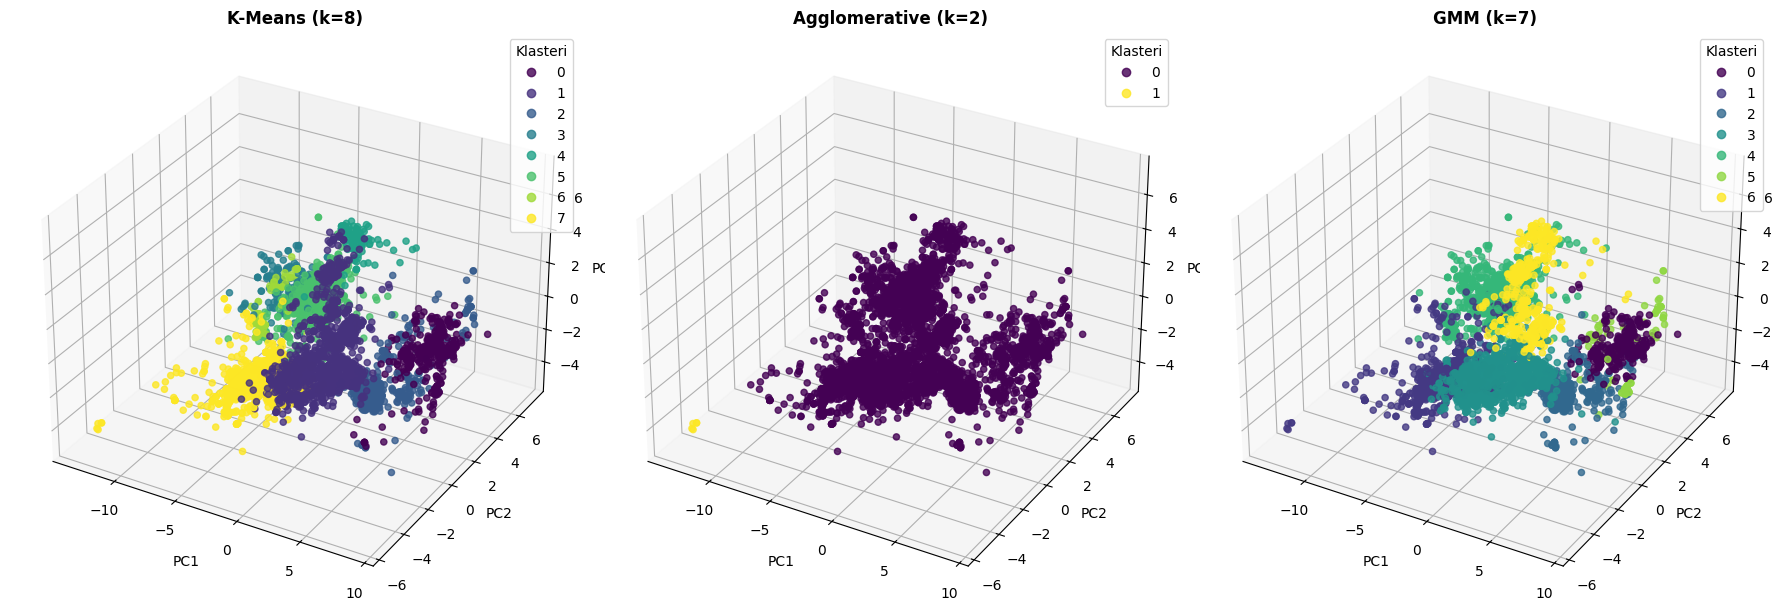

In [15]:
res_all = run_hantavirus_clustering_pipeline(all_3_mers, n_components=0.8, plot=True)

In [20]:
agg_single_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'],
    data=all_3_mers,
    segments=res_all['segments'],
    species=res_all['species'],
    model_name="Agglomerative (Single Linkage)"
)


========================= ANALIZA ZA: AGGLOMERATIVE (SINGLE LINKAGE) =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,881,1483,2810
1,0,0,5



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,438,1667,2823,246
1,0,0,5,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=5174, pretežno S segment) -> Orthohantavirus puumalaense: 2823 (54.6%), Orthohantavirus hantanense: 1667 (32.2%), Orthohantavirus dobravaense: 438 (8.5%)
  Klaster 1 (N=5, pretežno S segment) -> Orthohantavirus puumalaense: 5 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TGG (Z=0.00), AAA (Z=0.00), GAA (Z=0.00)
  Klaster 1 -> TTA (Z=6.71), ATT (Z=5.42), TAA (Z=5.10)


### Poređenje rezultata klasterovanja (svi podaci 3-meri, N = 5179)

* **Uticaj parcijalnih sekvenci na separaciju (K-Means i GMM):**
  * Primećuje se pad vrednosti silueta koeficijenta (K-Means: 0.2388, GMM: 0.2252) i rast Davies-Bouldin indeksa (1.47 i 1.64) u poredjenju sa 3-merima kompletnih sekvenci.
  * Povećanje broja dimenzija (20 PCA komponenti) otežava formiranje kompaktih klastera.

* **Problem jednostrukog povezivanja (Agglomerative - single linkage):**
  * Iako aglomerativni model ima najbolji silueta koeficijent 0.4899 to je posledica problema lančanja, odnosno u jednom manjem klasteru je nekoliko sekvenci, dok su sve ostale u drugom većem klasteru, što ne sadrži korisne biološke informacije. Iz ovog razloga je odbačen ovaj rezultat i ponovo je pokrenut algoritam sa wardovim povezivanjem.

In [16]:
best_params, best_metrics, agg_labels = optimize_and_print_agglomerative(
    res_all['X_pca'], 
    cluster_range=range(2, 9),
    linkages=['ward']
)

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 7
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silueta koeficijent: 0.2238
Davies-Bouldin indeks: 1.7797


In [17]:
res_all['labels']['agglomerative'] = agg_labels

In [18]:
res_all['params']['agglomerative'] = best_params
res_all['metrics']['agglomerative'] = best_metrics

In [19]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['kmeans'], 
    data = all_3_mers,
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'], 
    data = all_3_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['gmm'], 
    data = all_3_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,0,0,343
1,3,4,1463
2,0,1,641
3,6,179,0
4,0,111,0
5,45,999,21
6,0,184,0
7,827,5,347



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,288,30,0,25
1,2,5,1462,1
2,20,598,1,23
3,1,7,177,0
4,0,111,0,0
5,94,527,321,123
6,0,0,184,0
7,33,389,683,74



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=343, pretežno S segment) -> Orthohantavirus dobravaense: 288 (84.0%), Orthohantavirus hantanense: 30 (8.7%), Orthohantavirus sinnombreense: 25 (7.3%)
  Klaster 1 (N=1470, pretežno S segment) -> Orthohantavirus puumalaense: 1462 (99.5%), Orthohantavirus hantanense: 5 (0.3%), Orthohantavirus dobravaense: 2 (0.1%)
  Klaster 2 (N=642, pretežno S segment) -> Orthohantavirus hantanense: 598 (93.1%), Orthohantavirus sinnombreense: 23 (3.6%), Orthohantavirus dobravaense: 20 (3.1%)
  Klaster 3 (N=185, pretežno M segment) -> Orthohantavirus puumalaense: 177 (95.7%), Orthohantavirus hantanense: 7 (3.8%), Orthohantavirus dobravaense: 1 (0.5%)
  Klaster 4 (N=111, pretežno M segment) -> Orthohantavirus hantanense: 111 (100.0%)
  Klaster 5 (N=1065, pretežno M segment) -> Orthohantavirus hantanense: 527 (49.5%), Orthohantavirus puumalaense: 321 (30.1%), Orthohantavirus sinnombreense: 123 (11.5%)
  Klaster 6 (N=184, pretežno M segment) -> Orthohant

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=1177, pretežno S segment) -> Orthohantavirus puumalaense: 1175 (99.8%), Orthohantavirus hantanense: 1 (0.1%), Orthohantavirus sinnombreense: 1 (0.1%)
  Klaster 1 (N=1208, pretežno M segment) -> Orthohantavirus hantanense: 506 (41.9%), Orthohantavirus puumalaense: 502 (41.6%), Orthohantavirus sinnombreense: 109 (9.0%)
  Klaster 2 (N=691, pretežno S segment) -> Orthohantavirus puumalaense: 583 (84.4%), Orthohantavirus hantanense: 108 (15.6%)
  Klaster 3 (N=937, pretežno L segment) -> Orthohantavirus hantanense: 423 (45.1%), Orthohantavirus puumalaense: 388 (41.4%), Orthohantavirus sinnombreense: 87 (9.3%)
  Klaster 4 (N=357, pretežno S segment) -> Orthohantavirus dobravaense: 308 (86.3%), Orthohantavirus sinnombreense: 48 (13.4%), Orthohantavirus hantanense: 1 (0.3%)
  Klaster 5 (N=628, pretežno S segment) -> Orthohantavirus hantanense: 628 (100.0%)
  Klaster 6 (N=181, pretežno M segment) -> Orthohantavirus puumalaense: 180 (99.4%), 

Segment,L,M,S
Cluster,,,
0,0,3,282
1,878,5,49
2,0,1,644
3,0,0,1365
4,3,1385,3
5,0,0,77
6,0,89,395



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,282,3,0,0
1,38,421,392,81
2,26,566,0,53
3,0,1,1361,3
4,92,508,682,109
5,0,77,0,0
6,0,91,393,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=285, pretežno S segment) -> Orthohantavirus dobravaense: 282 (98.9%), Orthohantavirus hantanense: 3 (1.1%)
  Klaster 1 (N=932, pretežno L segment) -> Orthohantavirus hantanense: 421 (45.2%), Orthohantavirus puumalaense: 392 (42.1%), Orthohantavirus sinnombreense: 81 (8.7%)
  Klaster 2 (N=645, pretežno S segment) -> Orthohantavirus hantanense: 566 (87.8%), Orthohantavirus sinnombreense: 53 (8.2%), Orthohantavirus dobravaense: 26 (4.0%)
  Klaster 3 (N=1365, pretežno S segment) -> Orthohantavirus puumalaense: 1361 (99.7%), Orthohantavirus sinnombreense: 3 (0.2%), Orthohantavirus hantanense: 1 (0.1%)
  Klaster 4 (N=1391, pretežno M segment) -> Orthohantavirus puumalaense: 682 (49.0%), Orthohantavirus hantanense: 508 (36.5%), Orthohantavirus sinnombreense: 109 (7.8%)
  Klaster 5 (N=77, pretežno S segment) -> Orthohantavirus hantanense: 77 (100.0%)
  Klaster 6 (N=484, pretežno S segment) -> Orthohantavirus puumalaense: 393 (81.2%), Ortho

## Interpretacija klastera (3-meri svih sekvenci, N = 5179)

Uvođenjem parcijalnih sekvenci u analizu i dalje je prisutno određeno odvajanje vrsta po S segmentu, ali sa manje čistoće u odnosu na klastere formirane na skupu kompletnih sekvenci. Većina L segmenata čini jedan dominantan klaster uz manji broj sekvenci raspoređenih po različitim klasterima, slično kao i M segmenti koji su u sva tri algoritma raspoređeni većinski u jednom mešovitom klasteru, ali sa nešto većim udelom raspoređenim po ostalim klasterima u odnosu na L segmente.

U narednoj tabeli su prikazani značajni 3-meri koji su se izdvojili K-Means klasterovanjem, a slični rezultati su dobijeni i pomoću aglomerativnog klasterovanja i GMM-a.

### Ključni 3-mer biomarkeri po klasterima (K-Means, N = 5179)

| Klaster | Dominantni segment i vrsta | Ključni 3-meri | Raspon Z-skora | 
|---|---|---|---|
| **Klaster 0** | S segment, *O. dobravaense* (84.0%) | `TCG`, `ACC` | 1.74 - 1.93 |
| **Klaster 1** | S segment, *O. puumalaense* (99.5%) | `ATG`, `CCC` | 0.85 - 0.97 |
| **Klaster 2** | S segment, *O. hantanense* (93.1%) | `GGG`, `GCA` | 1.36 - 1.45 | 
| **Klaster 3** | M segment, *O. puumalaense* (95.7%) | `GTA`, `TTG` | 2.03 - 2.32 |
| **Klaster 4** | M segment, *O. hantanense* (100%) | `CAC`, `ACA` | 2.62 - 2.91 | 
| **Klaster 5** | M segment, mešovite vrste | `TCT`, `TGT` | 0.83 - 0.96 | 
| **Klaster 6** | M segment, *O. puumalaense* (100%) | `TGT`, `TGA` | 1.91 - 2.14 | 
| **Klaster 7** | L segment, mešovite vrste | `TTA`, `ATA` | 1.00 - 1.22 |

Na skupu svih sekvenci (5179 uzoraka i 20 PCA komponenti), parcijalni segmenti različitih dužina popunjavaju prazan prostor između grupa i prave mostove među njima. Kod kompletnih genoma granice su bile oštre, dok se ovde stvaraju mešovitiji rezultati.

# Čuvanje rezultata

In [21]:
row_complete = extract_kmer_summary(res_complete, k_val=3, dataset_type='Complete')

In [22]:
row_all = extract_kmer_summary(res_all, k_val=3, dataset_type='All')

In [23]:
summary_3_mers = pd.DataFrame([row_complete, row_all])

In [24]:
output_path = '../data/sequences_kmers/summary_3_mers.csv'
summary_3_mers.to_csv(output_path, index=False)

In [25]:
summary_3_mers

,k,Dataset,Features,PCA_comps,KMeans_k,KMeans_Sil,KMeans_DB,GMM_k,GMM_Sil,GMM_DB,Agg_k,Agg_linkage,Agg_Sil,Agg_DB
0,3,Complete,64,9,7,0.5559,0.7669,4,0.5379,0.8741,7,complete,0.5641,0.6959
1,3,All,64,20,8,0.2388,1.4699,7,0.2252,1.6411,7,ward,0.2238,1.7797
